Copernicus Land Monitoring Service (CLMS) provides a wide range of geospatial data products on land cover and its changes, land use, ground motion, vegetation state, watercyle and earth surdace energy varibales for both Europe and entire globe. All these products are availbale free of charge and can be use for any purpose. These prodcuts can be directly accessed in the Copernicus Data Space Ecosystem using several data access and processing APIs.

One of the APIs is openEO API which provides a standardised way to access and process geospatial data on the cloud. The openEO API is a community driven initiative and can be used with several programming languages including Python, R, Java and JavaScript. In this notebook we will use the Python client to access and process CLMS data products.

The main purpose of this notebook is to demonstrate how to access and process CLMS data products using openEO API. We will use the following CLMS data products in this notebook:
- CLMS Land Cover Map (LCM) Global 10m Yearly V1
- CLMS Soil Moisture (SSM) Europe 1km Daily V1
- CLMS Burnt Area (BA) Global 300m daily V4

In [29]:
# import the necessary packages

import openeo
from openeo import MultiResult
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors

In [2]:
# establish the connection and authenticate
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [3]:
collections = connection.list_collections()
collection_overview = []
# Filter collections with "CLMS" in their title
for collection in collections:
    if "title" in collection and "CLMS" in collection["title"]:
        gsd = collection.get('summaries', {}).get('gsd', [None])[0]
        collection_overview.append(
            {
                "Collection ID": collection.get('id'),
                "Title": collection.get('title'),
                "Description": collection.get('description')
            }
        )

collection_overview_df = pd.DataFrame(collection_overview)
print(f"Found {len(collection_overview_df)} collections with 'CLMS' in the title.")
# Pretty print with full column width and no truncation
with pd.option_context('display.max_colwidth', None):
    display(collection_overview_df[:10])

Found 109 collections with 'CLMS' in the title.


,Collection ID,Title,Description
0,CLMS_LCM_GLOBAL_10M_YEARLY_V1,CLMS Land Cover Map (LCM) Global 10m yearly V1 (COG),"Provides at global level information on different types (classes) of physical coverage of the Earth's surface, e.g. tree cover, grasslands, croplands, permanent water bodies, wetlands at 10 m spatial resolution for the 2020 base year. The data are updated annually and will be available for the 2020-2026 years. This dataset builds upon initiatives like the 100 m Copernicus Global Land Cover layers (2015-2019) and offers enhanced spatial detail that facilitates more effective monitoring of global land cover changes, including deforestation, urbanization, and other environmental transformations."
1,CLMS_TCD_PANTROPICAL_10M_YEARLY_V1,CLMS Tree Cover Density (TCD) Pantropical 10m yearly V1 (COG),"Provides pantropical tree cover density as projective tree cover in percent per pixel at 10 m resolution for the 2020 base year. The product belongs to the Copernicus Global Land Cover and Tropical Forest Mapping and Monitoring Service (LCFM) and builds upon initiatives like the REDDCopernicus, EO4SD Forest Monitoring and pan-European Vegetated Land Cover Characteristics. It advances tropical forest monitoring capabilities, ensuring alignment with international sustainability initiatives and providing critical information for analysis and monitoring of deforestation and forest degradation."
2,CLMS_BA_GLOBAL_300M_DAILY_V4,CLMS Burnt Area (BA) Global 300m daily V4 (COG),"Maps burn scars, surfaces which have been sufficiently affected by fire to display significant changes in the vegetation cover (destruction of dry material, reduction or loss of green material) and in the ground surface (temporarily darker because of ash). Daily datasets are available at global scale, in the spatial resolution of 300 m, and within 24 hours after the satellite acquisition. They cover the period from January 2025 to present."
3,CLMS_NDVI_GLOBAL_300M_10DAILY_V3,CLMS Normalized Difference Vegetation Index (NDVI) Global 300m 10-daily v3 (COG),NDVI is an indicator of the greenness of the biomes. Every 10-days estimates are available in near real time at global scale in the spatial resolution of about 300 m from January 2014 to the present.
4,CLMS_ETA_GLOBAL_300M_10DAILY_V1,CLMS Evapotranspiration (ETA) Global 300m 10-daily V1 (COG),"Provides actual evapotranspiration, soil evaporation and canopy transpiration with some quality indicators. Estimates are provided for two evapotranspiration schemes and an Ensemble of models. The 10-daily estimates are available at global scale in the spatial resolution of 300 m from November 2025 to present, derived from Sentinel-3 OLCI and SLSTR data."
5,CLMS_HF_GLOBAL_300M_DAILY_V1,CLMS Heat Flux (HF) Global 300m daily V1 (COG),Provides latent and sensible heat fluxes with one auxiliary information. Estimates are provided for each Sentinel-3 overpass in near real time at global scale in the spatial resolution of about 300 m from November 2025 onwards.
6,CLMS_LSP_GLOBAL_300M_YEARLY_V2,CLMS Land Surface Phenology (LSP) Global 300m yearly V2 (COG),Provides yearly Land Surface Phenology parameters describing when change happened in time and how intensive it was during key phases of the vegetation development cycle. Annual products are available at global scale in the spatial resolution of 300 m from 2014 to 2024.
7,CLMS_SSM_EUROPE_1KM_DAILY_V1,CLMS Surface Soil Moisture (SSM) Europe 1km daily v1 (COG),"Provides information on the relative water content of the top few centimeters soil, describing how wet or dry the soil is in its topmost layer, expressed in percent saturation. Daily observations are available for the continental Europe in the spatial resolution of 1 km and with the temporal extent from October 2014 to present."
8,CLMS_NPP_GLOBAL_300M_10DAILY_V2,CLMS Net Primary Production (NPP) Global 300m 10-daily V2 (COG),"Defined as the net amount of biomass, or carbon, produced by plants per unit area and time, expr

As you can see above there are more than 100 CLMS data products that can be access using openEO. For more information on the CLMS data products, please refer to the [CLMS Data Products](https://land.copernicus.eu/global/products) page.

Example: Land cover over Belgium (CLMS_LCM_GLOBAL_10M_YEARLY_V1)

A simple example of accessing and visualising CLMS data products is to access the CLMS Land Cover Map (LCM) Global 10m Yearly V1 product for Belgium and visualise it. In the following example we use `load_collection` process of the openEO API to access the CLMS LCM product for a region of Antwerp in Belgium. In the similar manner, you can access other CLMS products using the openEO API. 

In [25]:
connection.describe_collection("CLMS_LCM_GLOBAL_10M_YEARLY_V1")

{'bands': [{'description': 'MAP', 'name': 'map'}],
 'contacts': [{'emails': [{'roles': ['contact point'],
     'value': 'copernicus@eea.europa.eu'}],
   'links': [{'href': 'https://land.copernicus.eu/',
     'rel': 'about',
     'title': 'Homepage of the Copernicus Land Monitoring Service',
     'type': 'text/html'}],
   'name': 'Copernicus Land Monitoring Service',
   'organization': 'European Environment Agency',
   'phones': [{'roles': ['contact point'], 'value': '+4533367100'}],
   'roles': ['producer']}],
 'cube:dimensions': {'bands': {'type': 'bands', 'values': ['map']},
  't': {'extent': ['2020-01-01T00:00:00Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-179.9999999, 179.9999999],
   'reference_system': 4326,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-60.0, 84.0],
   'reference_system': 4326,
   'type': 'spatial'}},
 'description': "Provides at global level information on different types (classes) of physical coverage of the Earth's surface, e.g. tree cover, grasslands, croplands, permanent water bodies, wetlands at 10 m spatial resolution for the 2020 base year. The data are updated annually and will be available for the 2020-2026 years. This dataset builds upon initiatives like the 100 m Copernicus Global Land Cover layers (2015-2019) and offers enhanced spatial detail that facilitates more effective monitoring of global land cover changes, including deforestation, urbanization, and other environmental transformations.",
 'experimental': True,
 'extent': {'spatial': {'bbox': [[-179.9999999, -60.0, 179.9999999, 84.0]]},
  'temporal': {'interval': [['2020-01-01T00:00:00Z', None]]}},
 'id': 'CLMS_LCM_GLOBAL_10M_YEARLY_V1',
 'keywords': ['Copernicus',
  'CLMS',
  'LCM',
  'Land Cover',
  'land use land cover',
  'global',
  'yearly',
  '10m',
  'Sentinel-2',
  'MSI'],
 'license': 'other',
 'links': [{'href': 'https://land.copernicus.eu/en/data-policy',
   'rel': 'license',
   'title': 'Data policy for Copernicus Land Monitoring Service products and services',
   'type': 'text/html'},
  {'href': 'https://land.copernicus.eu/en/products/global-dynamic-land-cover/land-cover-2020-raster-10-m-global-annual',
   'rel': 'about',
   'title': 'Product page',
   'type': 'text/html'},
  {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/clms_lcm_global_10m_yearly_v1_cog',
   'rel': 'derived_from',
   'type': 'application/json'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_LCM_GLOBAL_10M_YEARLY_V1',
   'rel': 'self'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_LCM_GLOBAL_10M_YEARLY_V1/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'}],
 'providers': [{'name': 'CloudFerro',
   'roles': ['host'],
   'url': 'https://cloudferro.com/'},
  {'name': 'European Environment Agency',
   'roles': ['producer'],
   'url': 'https://land.copernicus.eu/'},
  {'name': 'European Commission',
   'roles': ['licensor'],
   'url': 'https://commission.europa.eu/'},
  {'name': 'VITO', 'roles': ['processor'], 'url': 'https://vito.be/'}],
 'sci:doi': '10.2909/602507b2-96c7-47bb-b79d-7ba25e97d0a9',
 'stac_extensions': ['https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/contacts/v1.0.0/schema.json',
  'https://stac-extensions.github.

In [4]:
# around Antwerp
landcover_cube = connection.load_collection(
    "CLMS_LCM_GLOBAL_10M_YEARLY_V1",
    spatial_extent={"west": 4.35, "south": 51.15, "east": 4.55, "north": 51.30},
    temporal_extent=["2020-01-01", "2021-01-01"],
    bands=["map"],
)

In [5]:
landcover_job = landcover_cube.create_job(title= "Landcover Antwerp 2024")
landcover_job.start_and_wait()

0:00:00 Job 'j-2609081240114b5d82a43570b2a5d436': send 'start'
0:00:06 Job 'j-2609081240114b5d82a43570b2a5d436': queued (progress 0%)
0:00:11 Job 'j-2609081240114b5d82a43570b2a5d436': queued (progress 0%)
0:00:18 Job 'j-2609081240114b5d82a43570b2a5d436': queued (progress 0%)
0:00:26 Job 'j-2609081240114b5d82a43570b2a5d436': queued (progress 0%)
0:00:36 Job 'j-2609081240114b5d82a43570b2a5d436': running (progress N/A)
0:00:48 Job 'j-2609081240114b5d82a43570b2a5d436': running (progress N/A)
0:01:04 Job 'j-2609081240114b5d82a43570b2a5d436': running (progress N/A)
0:01:23 Job 'j-2609081240114b5d82a43570b2a5d436': running (progress N/A)
0:01:47 Job 'j-2609081240114b5d82a43570b2a5d436': running (progress N/A)
0:02:17 Job 'j-2609081240114b5d82a43570b2a5d436': finished (progress 100%)


<BatchJob job_id='j-2609081240114b5d82a43570b2a5d436'>

In [6]:
result = landcover_job.get_results()
result_2024 = landcover_job.get_results()

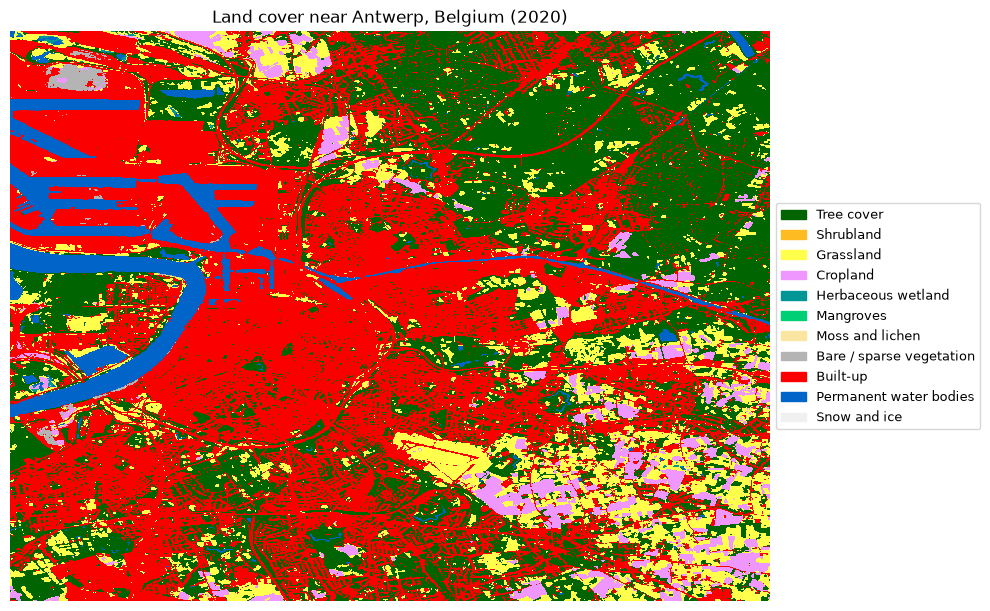

In [34]:
# classes from https://stac.dataspace.copernicus.eu/v1/collections/clms_lcm_global_10m_yearly_v1_cog
LCM_LEGEND = {
    10: ("Tree cover", "#006400"),
    20: ("Shrubland", "#FFBB22"),
    30: ("Grassland", "#FFFF4C"),
    40: ("Cropland", "#F096FF"),
    50: ("Herbaceous wetland", "#009696"),
    60: ("Mangroves", "#00CF75"),
    70: ("Moss and lichen", "#FAE6A0"),
    80: ("Bare / sparse vegetation", "#B4B4B4"),
    90: ("Built-up", "#FA0000"),
    100: ("Permanent water bodies", "#0064C8"),
    110: ("Snow and ice", "#F0F0F0"),
}

img = rasterio.open("landcover_2020/openEO_2020-01-01Z.tif").read(1, masked=True)
img = np.ma.masked_invalid(img)

cmap = matplotlib.colors.ListedColormap([color for _, color in LCM_LEGEND.values()])
bounds = list(LCM_LEGEND.keys()) + [255]
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(
    img,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    aspect="equal",
)
ax.set_title("Land cover near Antwerp, Belgium (2020)")
ax.set_axis_off()

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=color) for _, color in LCM_LEGEND.values()
]
ax.legend(
    legend_patches,
    [name for name, _ in LCM_LEGEND.values()],
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    frameon=True,
)
plt.tight_layout()
plt.show()

While in the above case we simply access one of the interesting CLMS products and visualised it. However, more analysis can be done using the openEO API. For example, we can use the CLMS Burnt Area and Soil Moisture products to study the impact of wildfires on soil moisture. For this, let us make a simple analysis of the impact of wildfires on soil moisture using the CLMS Burnt Area and Soil Moisture products.

Example: Burnt area and post-fire soil moisture (Gironde wildfires, France)

The Kalmthoutse Heide fire (~40 ha) turned out to be too small for the 300 m Burnt Area product to detect (see the year-scan below - every month is 0.0). Instead, this example uses the large, well-documented July 2022 wildfires in the Gironde/Landes region of southwest France (tens of thousands of hectares burned), which the global 300 m product is designed to pick up:
- `CLMS_BA_GLOBAL_300M_MONTHLY_V4` – Burnt Area (monthly, 300 m) to see the burn scar.
- `CLMS_SSM_EUROPE_1KM_DAILY_V1` – Surface Soil Moisture (daily, 1 km) to compare soil moisture before vs. after the fire.

In [27]:
connection.describe_collection("CLMS_BA_GLOBAL_300M_MONTHLY_V4")

{'bands': [{'description': 'Day of burn in year (1-366), no burn (0) or flag (<0)',
   'name': 'dob_ntc'},
  {'description': 'Probability that the fractional burned area is above 0.1',
   'name': 'lfp_ntc'},
  {'description': 'Fraction of pixel surface affected by fire at the day of the burn detection',
   'name': 'bf_ntc'},
  {'description': 'Probability that the burn detection corresponds to an actual burn',
   'name': 'cp_ntc'}],
 'contacts': [{'emails': [{'roles': ['contact point'],
     'value': 'copernicus@eea.europa.eu'}],
   'links': [{'href': 'https://land.copernicus.eu/',
     'rel': 'about',
     'title': 'Homepage of the Copernicus Land Monitoring Service',
     'type': 'text/html'}],
   'name': 'Copernicus Land Monitoring Service',
   'organization': 'European Environment Agency',
   'phones': [{'roles': ['contact point'], 'value': '+4533367100'}],
   'roles': ['producer']}],
 'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['dob_ntc', 'lfp_ntc', 'bf_ntc', 'cp_ntc']},
  't': {'extent': ['2018-07-01T00:00:00Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-179.9999999, 179.9985119],
   'reference_system': 4326,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [-59.9985119, 80.0014881],
   'reference_system': 4326,
   'type': 'spatial'}},
 'description': 'Maps burn scars, surfaces which have been sufficiently affected by fire to display significant changes in the vegetation cover (destruction of dry material, reduction or loss of green material) and in the ground surface (temporarily darker because of ash). In addition to the date of burn, the Burnt Areas version 4.0 provides the burnt fraction of the pixel. Monthly datasets are available at global scale, in the spatial resolution of 300 m, and with a time lag of few months. They cover the period from July 2018 to present.',
 'experimental': True,
 'extent': {'spatial': {'bbox': [[-179.9999999,
     -59.9985119,
     179.9985119,
     80.0014881]]},
  'temporal': {'interval': [['2018-07-01T00:00:00Z', None]]}},
 'id': 'CLMS_BA_GLOBAL_300M_MONTHLY_V4',
 'keywords': ['Copernicus',
  'CLMS',
  'BA',
  'Burnt Area',
  'fire disturbance',
  'global',
  'monthly',
  '300m',
  'Sentinel-3',
  'OLCI',
  'SLSTR'],
 'license': 'other',
 'links': [{'href': 'https://land.copernicus.eu/en/data-policy',
   'rel': 'license',
   'title': 'Data policy for Copernicus Land Monitoring Service products and services',
   'type': 'text/html'},
  {'href': 'https://land.copernicus.eu/en/products/vegetation/burnt-area-v4-monthly-300m',
   'rel': 'about',
   'title': 'Product page',
   'type': 'text/html'},
  {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/clms_ba_global_300m_monthly_v4_cog',
   'rel': 'derived_from',
   'type': 'application/json'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_BA_GLOBAL_300M_MONTHLY_V4',
   'rel': 'self'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_BA_GLOBAL_300M_MONTHLY_V4/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'}],
 'providers': [{'name': 'CloudFerro',
   'roles': ['host'],
   'url': 'https://cloudferro.com/'},
  {'name': 'European Environment Agency',
   'roles': ['producer'],
   'url': 'https://land.copernicus.eu/'},
  {'name': 'European Commission',
   'roles': ['licensor'],
   'url': 'https://commission.europa.eu/'},
  {'name': 'VITO', 'roles': ['processor'], 'url': 'https://vito.be/'}],
 'sci:doi': '10.2909/8fa58061-28ab-49bb-9b77-c26b50733e34',
 'stac_extensions': ['https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.jso

In [17]:
# Landes/Gironde forest fires, France (fire occurred July 2022)
# bf_ntc: fraction of the pixel actually burned: it directly gives the fraction of each pixel actually burned, which is the most intuitive band for mapping burn extent/severity.
# AOI widened/shifted to safely enclose both named fire locations reported by
# French civil protection: La Teste-de-Buch (~44.63N, 1.15W) and Landiras (~44.53N, 0.2W)
fire_extent = {"west": -1.35, "south": 44.35, "east": -0.05, "north": 44.75}
burnt_area_cube = connection.load_collection(
    "CLMS_BA_GLOBAL_300M_MONTHLY_V4",
    spatial_extent=fire_extent,
    temporal_extent=["2022-07-01", "2022-07-31"],
    bands=["bf_ntc"],
).reduce_dimension(dimension="t", reducer="first")

burnt_area_cube.download("burnt_area_gironde_2022_07.tiff")

In the above example, we simply downloaded the first available image for the region of interest in Gironde, France. With a quick visual inspection, we can see that the burnt area is clearly visible in the image. However, to study the impact of wildfires on soil moisture, we need to compare the soil moisture before and after the fire. For this, we will use the `CLMS_SSM_EUROPE_1KM_DAILY_V1` product to access the soil moisture data for the region of interest in Gironde, France.


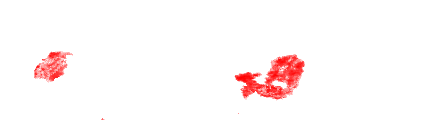

In [42]:
# Interactive burnt-area map using the existing fire_extent bbox.
# Only burned pixels are overlaid so the fire scar remains visible above the basemap.

import folium


def plot_burnt_area_interactive(raster_path, extent):
    with rasterio.open(raster_path) as src:
        arr = src.read(1, masked=True)
        arr = np.ma.masked_invalid(arr)

    burn_mask = np.ma.where(arr > 0.1, arr, 0.0)
    burn_mask = np.ma.filled(burn_mask, 0.0)

    minx, miny, maxx, maxy = extent["west"], extent["south"], extent["east"], extent["north"]
    center = [(miny + maxy) / 2, (minx + maxx) / 2]

    m = folium.Map(location=center, zoom_start=9, tiles="OpenStreetMap")
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri",
        name="Esri Satellite",
        overlay=False,
    ).add_to(m)

    folium.raster_layers.ImageOverlay(
        image=burn_mask,
        bounds=[[miny, minx], [maxy, maxx]],
        colormap=lambda x: (1, 0, 0, min(max(x, 0), 1)),
        opacity=0.8,
    ).add_to(m)

    folium.LayerControl().add_to(m)
    return m


plot_burnt_area_interactive("burnt_area_gironde_2022_07.tiff", fire_extent)

In [ ]:
ba_img = rasterio.open("burnt_area_gironde_2022_07.tiff").read(1, masked=True)
ba_img = np.ma.masked_invalid(ba_img)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ba_img, cmap="hot", vmin=0, vmax=1, interpolation="nearest", aspect="equal")
ax.set_title("Burnt Area - Landes/Gironde, France (July 2022)")
ax.set_axis_off()
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04, label="Burned fraction of pixel")
plt.tight_layout()
plt.show()

In [19]:
# sanity check: the "hot" colormap renders NaN/nodata pixels as white, which can look like burnt patches
pixel_area_ha = 300 * 300 / 10_000  # 300m resolution -> hectares per pixel
nodata_pixels = np.isnan(ba_img).sum()
valid = ba_img[~np.isnan(ba_img)]
burnt_pixels = (valid > 0.1).sum()
estimated_burnt_area_ha = valid[valid > 0.1].sum() * pixel_area_ha

print(f"AOI size: {ba_img.shape[0]} x {ba_img.shape[1]} pixels ({ba_img.size * pixel_area_ha:.0f} ha)")
print(f"NaN / nodata pixels: {nodata_pixels}")
print(f"Valid (non-NaN) pixel value range: {valid.min():.3f} - {valid.max():.3f}")
print(f"Pixels with burned fraction > 0.1: {burnt_pixels}")
print(f"Estimated burnt area: {estimated_burnt_area_ha:.1f} ha")

AOI size: 135 x 438 pixels (532170 ha)
NaN / nodata pixels: 7695
Valid (non-NaN) pixel value range: 0.000 - 0.885
Pixels with burned fraction > 0.1: 2509
Estimated burnt area: 11811.7 ha


Therefore, in the following example, we will use the `load_collection` process of the openEO API to access the CLMS Burnt Area and Soil Moisture products for the region of interest in Gironde, France .We will use the `reduce_dimension` process to calculate the mean soil moisture before and after the fire and visualise the results.

In [28]:
connection.describe_collection("CLMS_SSM_EUROPE_1KM_DAILY_V1")

{'bands': [{'description': 'Noise on Surface Soil Moisture', 'name': 'noise'},
  {'description': 'Surface Soil Moisture', 'name': 'ssm'}],
 'contacts': [{'emails': [{'roles': ['contact point'],
     'value': 'copernicus@eea.europa.eu'}],
   'links': [{'href': 'https://land.copernicus.eu/',
     'rel': 'about',
     'title': 'Homepage of the Copernicus Land Monitoring Service',
     'type': 'text/html'}],
   'name': 'Copernicus Land Monitoring Service',
   'organization': 'European Environment Agency',
   'phones': [{'roles': ['contact point'], 'value': '+4533367100'}],
   'roles': ['producer']}],
 'cube:dimensions': {'bands': {'type': 'bands', 'values': ['noise', 'ssm']},
  't': {'extent': ['2014-10-04T00:00:00Z', None], 'type': 'temporal'},
  'x': {'axis': 'x',
   'extent': [-11.0, 50.0],
   'reference_system': 4326,
   'type': 'spatial'},
  'y': {'axis': 'y',
   'extent': [35.0, 72.0],
   'reference_system': 4326,
   'type': 'spatial'}},
 'description': 'Provides information on the relative water content of the top few centimeters soil, describing how wet or dry the soil is in its topmost layer, expressed in percent saturation. Daily observations are available for the continental Europe in the spatial resolution of 1 km and with the temporal extent from October 2014 to present.',
 'experimental': True,
 'extent': {'spatial': {'bbox': [[-11.0, 35.0, 50.0, 72.0]]},
  'temporal': {'interval': [['2014-10-04T00:00:00Z', None]]}},
 'id': 'CLMS_SSM_EUROPE_1KM_DAILY_V1',
 'keywords': ['Copernicus',
  'CLMS',
  'SSM',
  'Surface Soil Moisture',
  'soil moisture',
  'Europe',
  'daily',
  '1km',
  'Sentinel-1',
  'C-SAR'],
 'license': 'other',
 'links': [{'href': 'https://land.copernicus.eu/en/data-policy',
   'rel': 'license',
   'title': 'Data policy for Copernicus Land Monitoring Service products and services',
   'type': 'text/html'},
  {'href': 'https://land.copernicus.eu/en/products/soil-moisture/daily-surface-soil-moisture-v1.0',
   'rel': 'about',
   'title': 'Product page',
   'type': 'text/html'},
  {'href': 'https://stac.dataspace.copernicus.eu/v1/collections/clms_ssm_europe_1km_daily_v1_cog',
   'rel': 'derived_from',
   'type': 'application/json'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'root'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections',
   'rel': 'parent'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_SSM_EUROPE_1KM_DAILY_V1',
   'rel': 'self'},
  {'href': 'https://openeo.dataspace.copernicus.eu/openeo/1.2/collections/CLMS_SSM_EUROPE_1KM_DAILY_V1/queryables',
   'rel': 'http://www.opengis.net/def/rel/ogc/1.0/queryables',
   'type': 'application/schema+json'}],
 'providers': [{'name': 'European Environment Agency',
   'roles': ['producer'],
   'url': 'https://land.copernicus.eu/'},
  {'name': 'European Commission',
   'roles': ['licensor'],
   'url': 'https://commission.europa.eu/'},
  {'name': 'VITO', 'roles': ['processor'], 'url': 'https://vito.be/'},
  {'name': 'CloudFerro', 'roles': ['host'], 'url': 'https://cloudferro.com/'}],
 'sci:doi': '10.2909/e934b15f-7d48-4c6d-a9c6-6484488aa58f',
 'stac_extensions': ['https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/raster/v2.0.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/classification/v2.0.0/schema.json',
  'https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
  'https://stac-extensions.github.io/contacts/v1.0.0/schema.json'],
 'stac_version': '1.1.0',
 'summaries': {'bands': [{'data_type': 'float32',
    'description': 'Noise on Surface Soil Moist

In [20]:
ssm_before = connection.load_collection(
    "CLMS_SSM_EUROPE_1KM_DAILY_V1",
    spatial_extent=fire_extent,
    temporal_extent=["2022-06-01", "2022-06-30"],
    bands=["ssm"],
).reduce_dimension(dimension="t", reducer="mean")

# fire was still actively burning in August (see year-scan above) -> use September for "after" instead
ssm_after = connection.load_collection(
    "CLMS_SSM_EUROPE_1KM_DAILY_V1",
    spatial_extent=fire_extent,
    temporal_extent=["2022-09-01", "2022-09-30"],
    bands=["ssm"],
).reduce_dimension(dimension="t", reducer="mean")

ssm_diff = ssm_after - ssm_before
ssm_diff

In [21]:
# first result
ssm_before_result = ssm_before.save_result(format="GTiff", options={"filename_prefix": "SSM_Before"})
# second result
ssm_after_result = ssm_after.save_result(format="GTiff", options={"filename_prefix": "SSM_After"})
# save SSM difference for comparison as third result
ssm_diff_result = ssm_diff.save_result(format="GTiff", options={"filename_prefix": "SSM_Difference"})

In [22]:
multi_result_nbr = MultiResult([ssm_before_result, ssm_after_result, ssm_diff_result])
ssm_job = multi_result_nbr.create_job(title="Multiple save result SSM")
ssm_job.start_and_wait()

0:00:00 Job 'j-260908125354494faf613f0327f81cce': send 'start'
0:00:05 Job 'j-260908125354494faf613f0327f81cce': created (progress 0%)
0:00:11 Job 'j-260908125354494faf613f0327f81cce': queued (progress 0%)
0:00:17 Job 'j-260908125354494faf613f0327f81cce': queued (progress 0%)
0:00:25 Job 'j-260908125354494faf613f0327f81cce': queued (progress 0%)
0:00:35 Job 'j-260908125354494faf613f0327f81cce': queued (progress 0%)
0:00:47 Job 'j-260908125354494faf613f0327f81cce': running (progress N/A)
0:01:03 Job 'j-260908125354494faf613f0327f81cce': running (progress N/A)
0:01:22 Job 'j-260908125354494faf613f0327f81cce': running (progress N/A)
0:01:46 Job 'j-260908125354494faf613f0327f81cce': running (progress N/A)
0:02:17 Job 'j-260908125354494faf613f0327f81cce': finished (progress 100%)


<BatchJob job_id='j-260908125354494faf613f0327f81cce'>

In [23]:
results = ssm_job.get_results()
results.download_files("ssm")

[WindowsPath('ssm/SSM_After.tif'),
 WindowsPath('ssm/SSM_Before.tif'),
 WindowsPath('ssm/SSM_Difference.tif'),
 WindowsPath('ssm/job-results.json')]

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_29524\235117952.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


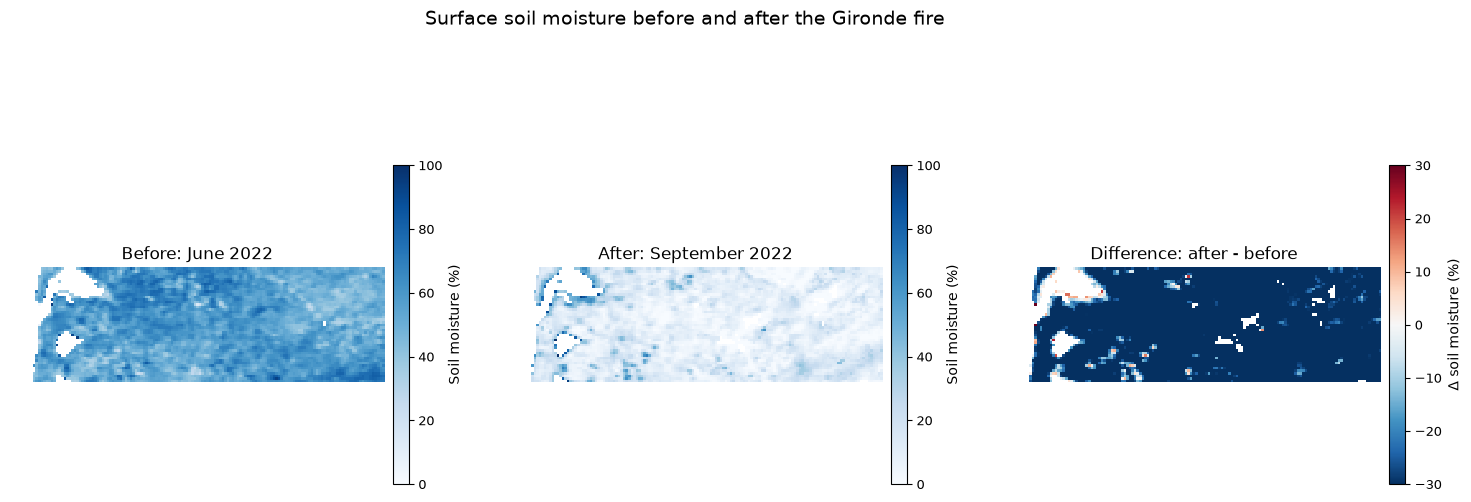

In [43]:
ssm_before_img = rasterio.open("ssm/SSM_Before.tif").read(1, masked=True)
ssm_after_img = rasterio.open("ssm/SSM_After.tif").read(1, masked=True)
ssm_diff_img = rasterio.open("ssm/SSM_Difference.tif").read(1, masked=True)

ssm_before_img = np.ma.masked_invalid(ssm_before_img)
ssm_after_img = np.ma.masked_invalid(ssm_after_img)
ssm_diff_img = np.ma.masked_invalid(ssm_diff_img)

# use a realistic scale for surface soil moisture and keep nodata transparent
vmin, vmax = 0, 100
diff_vmin, diff_vmax = -30, 30

fig, axarr = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"wspace": 0.25})

im0 = axarr[0].imshow(ssm_before_img, cmap="Blues", vmin=vmin, vmax=vmax, interpolation="nearest")
axarr[0].set_title("Before: June 2022", fontsize=12)
axarr[0].set_axis_off()
cbar0 = fig.colorbar(im0, ax=axarr[0], fraction=0.04, pad=0.02, shrink=0.9)
cbar0.set_label("Soil moisture (%)", fontsize=10)
cbar0.ax.tick_params(labelsize=9)

im1 = axarr[1].imshow(ssm_after_img, cmap="Blues", vmin=vmin, vmax=vmax, interpolation="nearest")
axarr[1].set_title("After: September 2022", fontsize=12)
axarr[1].set_axis_off()
cbar1 = fig.colorbar(im1, ax=axarr[1], fraction=0.04, pad=0.02, shrink=0.9)
cbar1.set_label("Soil moisture (%)", fontsize=10)
cbar1.ax.tick_params(labelsize=9)

im2 = axarr[2].imshow(ssm_diff_img, cmap="RdBu_r", vmin=diff_vmin, vmax=diff_vmax, interpolation="nearest")
axarr[2].set_title("Difference: after - before", fontsize=12)
axarr[2].set_axis_off()
cbar2 = fig.colorbar(im2, ax=axarr[2], fraction=0.04, pad=0.02, shrink=0.9)
cbar2.set_label("Δ soil moisture (%)", fontsize=10)
cbar2.ax.tick_params(labelsize=9)

fig.suptitle("Surface soil moisture before and after the Gironde fire", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Please note that the idea of this notebook is not to provide a complete scientific analysis of the impact of wildfires on soil moisture, but to demonstrate how to access and process CLMS data products using openEO API. 

Researchers are encouraged to use the API to access and process CLMS data products for their own research purposes.